<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/proentrega/entrega_alex6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de datos con Pyhon - Entrega 6    - dic-11 08:03
Nombre y apellido: DE GARATE, ESTEBAN ALEJANDRO  
   
Comisión: TT252813 - 2C2025 Lunes 19 hs
  
.   



# Etapa 1

## Script básico
Actividades 2 y 3

In [ ]:
# Generamos una lista de diccionarios que contenga algunos datos
ventas = [
  {'producto': 'notebook', 'precio': 1500.0, 'cantidad': 3},
  {'producto': 'monitor', 'precio': 500.0, 'cantidad': 5},
  {'producto': 'mouse', 'precio': 20.0, 'cantidad': 15}
]

In [ ]:
# Calculamos las ventas acumuladas - map
venta_acumuladas = sum( map( lambda venta: venta["precio"] * venta["cantidad"], ventas))
venta_acumuladas

7300.0

In [ ]:
# Calculamos las ventas acumuladas - listas por comprensión
venta_acumuladas = sum( [venta["precio"] * venta["cantidad"] for venta in ventas])
venta_acumuladas

7300.0

## Import Datasets
Actividad 1

In [1]:
import pandas as pd

In [2]:
# Import dataset ventas
url = "https://github.com/alex-degarate/TT-2C2025-Data-Analitycs-Notebooks/raw/refs/heads/main/PreEntrega/Datasets/"
df_ventas = pd.read_csv( url + "ventas.csv")


In [3]:
# Import dataset clientes
df_clientes = pd.read_csv( url + "clientes.csv")

In [4]:
# Import dataset marketing
df_marketing = pd.read_csv( url + "marketing.csv")

In [ ]:
df_ventas.head(3)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos


## Dataframe VENTAS

### Análisis exploratorio de **datos**
Actividad 4

Aplicamos los métodos de EDA vistos en clase, `info`, `columns`, `dtypes`, `head`, `tail`, `sample`, `unique`, `value_counts`, `describe`, `duplicated`, `isnull`, etc. y documentamos las observaciones:

In [5]:
# Aplicamos info() para familiarizarnos con el dataframe
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   object 
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 142.4+ KB


In [6]:
# Visualizamos los primeros registros con head()
# también podemos usar tail() para visualizar los últimos
df_ventas.head()

display(df_ventas.head())

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


In [7]:
# Usar sample() para tomar registros al azar
df_ventas.sample(5)

,id_venta,producto,precio,cantidad,fecha_venta,categoria
2802,1160,Plancha de vapor,$124.24,2.0,01/12/2024,Electrodomésticos
2380,1204,Aspiradora,$87.88,2.0,08/10/2024,Electrodomésticos
2685,431,Lámpara de mesa,$98.30,6.0,18/11/2024,Decoración
513,1569,Batidora,$122.02,12.0,29/02/2024,Electrodomésticos
2600,2335,Auriculares,$108.76,8.0,07/11/2024,Electrónica


In [8]:
# Analizamos el campo precio
# Si es numerico se puede aplicar describe()
df_ventas["precio"].sample(5)

,precio
710,$96.59
3022,$99.68
2292,$67.72
575,$39.67
1590,$72.74


In [9]:
# Analizamos el campo cantidad
# si es numerico se puede aplicar describe()
df_ventas["cantidad"].sample(5)

,cantidad
2419,2.0
941,8.0
1188,11.0
2317,5.0
1612,8.0


In [10]:
# Analizamos el campo fecha_venta
df_ventas["fecha_venta"].sample(5)

,fecha_venta
1913,11/08/2024
1464,13/06/2024
2521,27/10/2024
2745,25/11/2024
1967,18/08/2024


In [11]:
# Analizamos el campo categoria
# Probar con value_counts y unique
df_ventas["categoria"].value_counts()

,count
categoria,
Decoración,1015
Electrónica,1012
Electrodomésticos,1008


In [12]:
df_ventas["categoria"].unique()


array(['Decoración', 'Electrodomésticos', 'Electrónica'], dtype=object)

### Calidad de datos
Actividad 5

In [13]:
# Buscamos registros duplicados
df_ventas.duplicated().sum()

np.int64(35)

In [14]:
# Visualizamos los duplicados
# keep: 'first', 'last', False
df_ventas[df_ventas.duplicated(keep=False)].sort_values(by="id_venta")

,id_venta,producto,precio,cantidad,fecha_venta,categoria
820,56,Cortinas,$66.24,5.0,05/04/2024,Decoración
826,56,Cortinas,$66.24,5.0,05/04/2024,Decoración
832,145,Alfombra,$41.72,8.0,06/04/2024,Decoración
844,145,Alfombra,$41.72,8.0,06/04/2024,Decoración
878,204,Jarrón decorativo,$94.75,1.0,08/04/2024,Decoración
...,...,...,...,...,...,...
830,2545,Auriculares,$32.81,11.0,05/04/2024,Electrónica
883,2705,Auriculares,$87.29,2.0,08/04/2024,Electrónica
889,2705,Auriculares,$87.29,2.0,08/04/2024,Electrónica
831,2778,SmartWatch,$70.66,7.0,05/04/2024,Electrónica


In [15]:
# Buscamos datos nulos
df_ventas.isnull().sum()

,0
id_venta,0
producto,0
precio,2
cantidad,2
fecha_venta,0
categoria,0


In [16]:

# Visualizar los nulos
# df_ventas[df_ventas.isnull().any(axis=1)]
nulos_lista = df_ventas[df_ventas.isnull().any(axis=1)]
df_ventas[df_ventas.isnull().any(axis=1)]

,id_venta,producto,precio,cantidad,fecha_venta,categoria
136,627,Elementos de cerámica,NaN,NaN,17/01/2024,Decoración
139,2171,Parlantes Bluetooth,NaN,NaN,17/01/2024,Electrónica


In [17]:
# Hay 2 registros con nulos, en el mismo registro, los campos "precio" y "cantidad son nulos
# No se pueden rescatar y van a ser eliminados
nulos_numero  = len( nulos_lista)
nulos_porcentaje = nulos_numero * 100 / len(df_ventas)
print(f"Numero de nulos: {nulos_numero } registros")
print(f"Porcentaje de nulos: {nulos_porcentaje:.2f}% registros")


Numero de nulos: 2 registros
Porcentaje de nulos: 0.07% registros


In [18]:
# Analizar los precios de los NaN a ver que opciones tenemos
# df_ventas[df_ventas["producto"]=="Elementos de cerámica"]
# df_ventas["producto"].value_counts()
df_ventas["producto"].unique()


array(['Cuadro decorativo', 'Lámpara de mesa', 'Secadora', 'Heladera',
       'Horno eléctrico', 'Plancha de vapor', 'Proyector',
       'Rincón de plantas', 'Candelabro', 'Aspiradora',
       'Freidora eléctrica', 'Tablet', 'Cortinas', 'Adorno de pared',
       'Jarrón decorativo', 'Lavadora', 'Auriculares', 'Cámara digital',
       'Cafetera', 'Consola de videojuegos', 'Smartphone',
       'Elementos de cerámica', 'Espejo decorativo',
       'Parlantes Bluetooth', 'SmartWatch', 'Microondas', 'Batidora',
       'Alfombra', 'Televisor', 'Laptop'], dtype=object)

### Observaciones: VENTAS




* Cantidad de registros originales: 3035
* Columnas/campos originales: 6
* 35 registros duplicados &emsp; => eliminarlos
*  2 registros con datos nulos: id:[136, 139], < 0.1 % total &emsp; =>  dropna
* Campo precio: tipo objeto con `$`, removerlo y luego cambiar el dtype a float64
* Campo fecha: ajustar a dtype datetime

## Dataframe MARKETING

### Analisis exploratorio de datos

Aplicamos los métodos de EDA vistos en clase, `info`, `columns`, `dtypes`, `head`, `tail`, `sample`, `unique`, `value_counts`, `describe`, `duplicated`, `isnull`, etc. y documentamos las observaciones:

In [19]:
# Aplicamos info() para familiarizarnos con el dataframe
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     object 
 2   canal         90 non-null     object 
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     object 
 5   fecha_fin     90 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.3+ KB


In [ ]:
# Visualizamos los primeros registros con head()
# también podemos usar tail() para visualizar los últimos
pd.set_option('display.max_rows', None)
df_marketing.head()

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


In [ ]:
# Analizamos el campo costo
df_marketing["costo"].sample(5)

,costo
58,5.69
46,4.94
20,3.25
53,5.70
25,4.52


In [20]:
# Analizamos el campo fecha_inicio
df_marketing["fecha_inicio"].sample(5)

,fecha_inicio
71,23/10/2024
8,13/04/2024
52,19/08/2024
79,11/11/2024
65,28/09/2024


In [21]:
# Analizamos el campo fecha_fin
df_marketing["fecha_fin"].sample(5)

,fecha_fin
76,28/11/2024
47,22/09/2024
3,16/05/2024
78,23/12/2024
33,09/08/2024


### Calidad de los datos


In [22]:
# Buscamos registros duplicados
df_marketing.duplicated().sum()

np.int64(0)

In [23]:
df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     object 
 2   canal         90 non-null     object 
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     object 
 5   fecha_fin     90 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.3+ KB


.  

### Observaciones: MARKETING

El dataframe DF_MARKETING tiene 90 registros

No hay registros duplicados

El campo fecha_inicio es objeto &emsp; => cambiar a dtype datetime

El campo fecha_fin &emsp; es objeto &emsp; => cambiar a dtype datetime


.  


## Dataframe CLIENTES

### Analisis exploratorio de datos

In [24]:
# Aplicamos info() para familiarizarnos con el dataframe
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB


In [ ]:
#df_clientes[500:]

In [ ]:
# Visualizamos los primeros registros con head()
df_clientes.head(1)

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68


In [25]:
# Buscamos registros duplicados
df_clientes.duplicated().sum()

np.int64(0)

In [ ]:
# Buscamos datos nulos
df_clientes.isnull().sum()

,0
id_cliente,0
nombre,0
edad,0
ciudad,0
ingresos,0


.  


### Observaciones

El dataframe CLIENTES tiene 567 registros.

No hay registros duplicados

No hay registros con valores nulos

El campo ciudad tiene ciudades con vocales acentuadas (poner vocales sin acento)

El campo nombre tiene nombres con apostrofe (sacar apostrofe)

###Calidad de los datos

In [26]:
# visualizamos las ciudades con vocales acentuadas y tilde (áéíóúñ)
ciudades_acentos = df_clientes[df_clientes["ciudad"].str.contains(r'[áéíóúñ]',regex=True)]

#display(ciudades_acentos.head())
# df_clientes[df_clientes["ciudad"].str.contains('á')].count()     # => 39
# df_clientes[df_clientes["ciudad"].str.contains('é')].count()     # => 0
# df_clientes[df_clientes["ciudad"].str.contains('í')].count()     # => 44
# df_clientes[df_clientes["ciudad"].str.contains('ó')].count()     # => 49
# df_clientes[df_clientes["ciudad"].str.contains('ú')].count()     # => 0
# df_clientes[df_clientes["ciudad"].str.contains('ñ')].count()     # => 0

ciudades_acentos.count()


,0
id_cliente,132
nombre,132
edad,132
ciudad,132
ingresos,132


In [27]:
# reemplazamos las vocales acentuadas por otras sin acento
# y (opcionalmente) podemos guardar en una nueva columna "city_normal"
import re

def replace_accented(match):
    char = match.group(0)
    mapping = {'á': 'a', 'é': 'e', 'í': 'i', 'ó': 'o', 'ú': 'u'}
    return mapping.get(char, char)

# 1 y 2 funcionan OK
# 1 df_clientes['city_normal'] = df_clientes['ciudad'].str.replace(r'[áéíóú]', replace_accented, regex=True)
# 2
df_clientes['ciudad'] = df_clientes['ciudad'].str.replace(r'[áéíóú]', lambda match: replace_accented(match), regex=True)
'''
df_clientes['city_normal'] = df_clientes['ciudad'].str.replace('á','a')
df_clientes['city_normal'] = df_clientes['ciudad'].str.replace('é','e')
df_clientes['city_normal'] = df_clientes['ciudad'].str.replace('í','i')
df_clientes['city_normal'] = df_clientes['ciudad'].str.replace('ó','o')
df_clientes['city_normal'] = df_clientes['ciudad'].str.replace('ú','u')
# comparar resultados
display(df_clientes.loc[100:110,['ciudad', 'city_normal']].sample(10))
'''
display(df_clientes.loc[100:110,['ciudad']].sample(10))


,ciudad
110,Mar del Plata
105,Bahia Blanca
101,Salta
102,San Miguel de Tucuman
104,Merlo
109,Mar del Plata
107,Mar del Plata
108,Buenos Aires
103,Posadas
106,Bahia Blanca


In [28]:
# nombres con apostrofes u otros
# Esta linea busca caracteres distintos de letras y espacio
metodo1 = df_clientes[df_clientes["nombre"].str.strip().str.contains(r"[^a-zA-Z\s+]", regex=True)].count()

# Esta linea busca especificamente por apostrofe, guion medio y punto
metodo2 = df_clientes[df_clientes["nombre"].str.contains(r"['-.]", regex=True)].count()

print(f"Metodo 1:\n {metodo1}")
print(f"\nMetodo 2:\n {metodo2}")



Metodo 1:
 id_cliente    15
nombre        15
edad          15
ciudad        15
ingresos      15
dtype: int64

Metodo 2:
 id_cliente    15
nombre        15
edad          15
ciudad        15
ingresos      15
dtype: int64


.  

# Etapa 2



## Limpieza de datos
Actividad 1 - Limpiar el conjunto de datos eliminando duplicados y caracteres no deseados. Documentar el proceso y los resultados.

.  

### Dataframe VENTAS

* 35 duplicados, eliminarlos - se eliminaron 35 duplicados &emsp; => Ok
* Algunos nulos (2), 1% del faltante, dropna - se eliminaron 2 registros con 2 NaN
* Campo precio: encontre `$`, removerlo y luego cambiar el dtype a float64 - Ok
* Campo fecha: ajustar a dtype datetime - Ok

In [29]:
# Eliminamos registros duplicados
# atributos a evaluar, keep, ignore_index, inplace
df_ventas.drop_duplicates(inplace=True, ignore_index=True)

In [30]:
# Validamos que no haya duplicados
df_ventas.duplicated().sum()

np.int64(0)

In [31]:
# Eliminamos registros con datos nulos
df_ventas.dropna(inplace=True)

In [32]:
# Validamos que no haya nulos
# df_ventas.isnull().sum()
df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     2998 non-null   int64  
 1   producto     2998 non-null   object 
 2   precio       2998 non-null   object 
 3   cantidad     2998 non-null   float64
 4   fecha_venta  2998 non-null   object 
 5   categoria    2998 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 164.0+ KB


In [33]:
# Eliminamos el caracter especial $ de precio
# Normalización: usar replace()
# De ser necesario, podemos usar el atributo regex=True
df_ventas["precio"] = df_ventas["precio"].str.strip().str.replace("$", "")

In [34]:
# Validamos que precio no contenga $
df_ventas["precio"].sample(3)

,precio
1531,111.39
1825,70.70
1279,65.23


In [35]:
# Convertimos precio de str a float
# Podemos usar pd.to_numeric o astype o incluso combinarlos
df_ventas["precio"] = df_ventas["precio"].astype(float)


In [36]:
# Convertir el dtype de cantidad, de float64 a int64
df_ventas["cantidad"]= df_ventas["cantidad"].astype(int)

In [37]:
# Validar la conversion a int
df_ventas["cantidad"].dtypes


dtype('int64')

In [38]:
# Validamos campos numericos
df_ventas[["precio","cantidad"]].sample(3)

,precio,cantidad
2587,83.34,10
927,54.94,3
2256,64.56,11


In [39]:
# Convertir el campo fecha_venta a dtype datetime
# pd.to_datetime(df_ventas["fecha_venta"], format="%d/%m/%Y")
# pd.to_datetime(df_ventas["fecha_venta"], dayfirst=True)
df_ventas['fecha_venta'] = pd.to_datetime(df_ventas['fecha_venta'], format="%d/%m/%Y")

In [40]:
# Validar la conversion de fecha
df_ventas['fecha_venta'].dtype




dtype('<M8[ns]')

In [41]:
# Renombrar ventas["precio"] a ventas["precio_unit"]  porque me resulta confuso
df_ventas.rename(columns={"precio": "precio_unit"}, inplace=True)

In [42]:
# Validar cambios
df_ventas.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     2998 non-null   int64         
 1   producto     2998 non-null   object        
 2   precio_unit  2998 non-null   float64       
 3   cantidad     2998 non-null   int64         
 4   fecha_venta  2998 non-null   datetime64[ns]
 5   categoria    2998 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 164.0+ KB


In [43]:
# @title
# Hacemos una copia del DF ventas y guardamos a disco como csv
df_ventas_final = df_ventas.copy()

#df_ventas_final.to_csv("df_ventas_final.csv", index=False)

In [ ]:
df_ventas_final.head()


,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos


VENTAS  
El df_ventas_final contiene 2998 registros  
   

   

.  
  

================================================================================
  


### Dataframe marketing

ACCIONES

Convertir el campo fecha_inicio a dtype = datetime  
Convertir el campo fecha_fin    a dtype = datetime

In [44]:
# Convertir el campo fecha_inicio a dtype datetime
df_marketing['fecha_inicio'] = pd.to_datetime(df_marketing['fecha_inicio'], format="%d/%m/%Y")

In [45]:
# Convertir el campo fecha_fin a dtype datetime
df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'], format="%d/%m/%Y")

In [46]:
# Validamos los cambios
df_marketing[["fecha_inicio","fecha_fin"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha_inicio  90 non-null     datetime64[ns]
 1   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 1.5 KB


In [47]:
# Hacemos una copia del df_marketing
df_marketing_final = df_marketing.copy()

# Guardamos la copia a disco
#df_marketing_final.to_csv('df_marketing_final.csv', index=False)

df_marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


In [ ]:
df_marketing.head(9)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05
5,85,SmartWatch,TV,5.07,2024-04-01,2024-05-05
6,36,Plancha de vapor,Email,5.41,2024-04-02,2024-06-01
7,57,Batidora,Email,4.48,2024-04-10,2024-06-08
8,44,Adorno de pared,Email,5.08,2024-04-13,2024-05-10


   
   
### Dataframe clientes  


In [48]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB


In [ ]:
df_clientes.head()


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahia Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


In [49]:
# Hacemos una copia del df_clientes
df_clientes_final = df_clientes.copy()

# Guardamos la copia a disco
df_clientes_final.to_csv('df_clientes_final.csv', index=False)

.  

# **Transformación de datos**
Actividad 2 - Aplicar filtros y transformaciones para crear una tabla de ventas que muestre solo los productos con alto rendimiento.

In [50]:
df_ventas_final.head(2)

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración


In [60]:
# Transformación:
# Calculamos el valor de cada venta = precio_unit * cantidad

# Agregamos una nueva columna  valor_venta = monto
df_ventas_final["valor_venta"] = df_ventas_final["precio_unit"] * df_ventas["cantidad"]

In [61]:
# Visualizamos
df_ventas_final.head(2)

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5


In [62]:
# Agregación:
# Agrupar valor_venta por producto
# Sumamos las ventas dentro de cada grupo
tabla_ventas = (df_ventas_final.groupby("producto", as_index=False)["valor_venta"].sum())
tabla_ventas.head()

,producto,valor_venta
0,Adorno de pared,48093.49
1,Alfombra,44773.06
2,Aspiradora,50085.86
3,Auriculares,74175.58
4,Batidora,50979.20


In [63]:
# Usemos describe para analizar algunos valores del dataframe resultante
tabla_ventas.describe()

,valor_venta
count,30.000000
mean,48903.117333
std,13265.561715
min,11128.800000
25%,45601.920000
50%,48140.245000
75%,51092.960000
max,82276.380000


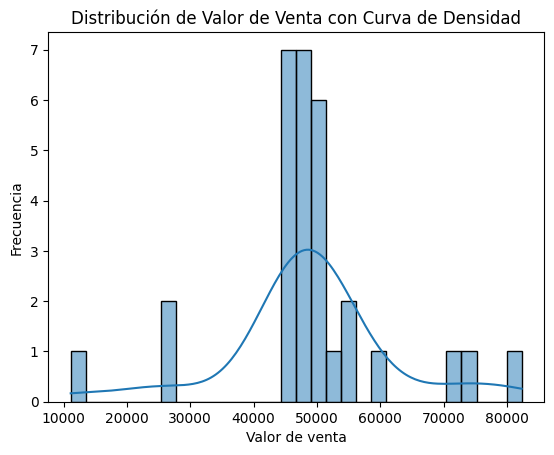

In [64]:
# Agregamos un plot para visualizar graficamente la distribución
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(tabla_ventas["valor_venta"], bins=30, kde=True, edgecolor="black")
plt.title("Distribución de Valor de Venta con Curva de Densidad")
plt.xlabel("Valor de venta")
plt.ylabel("Frecuencia")
plt.show()

### Alto Rendimiento
Los productos de alto rendimiento son aquellos que maximizan su utilidad, rentabilidad o eficiencia (se tomará quartil 75 )

In [65]:
# Calcular el percentil 75 (umbral de alto rendimiento)
umbral_ventas = tabla_ventas["valor_venta"].quantile(0.75)
umbral_ventas

np.float64(51092.96)

In [ ]:
# ventas por cantidad de producto
ventas_cant_prod = df_ventas_final.groupby("producto", as_index=False).agg(
    cant_vend=("cantidad", "sum")
)

In [ ]:
ventas_cant_prod.head(30)

In [101]:
# productos_top por cantidad vendida
prod_top_cant = ventas_cant_prod.sort_values(by="cant_vend", ascending=False).head(5)

In [102]:
prod_top_cant.head(5)

,producto,cant_vend
19,Lámpara de mesa,1112
3,Auriculares,958
20,Microondas,912
5,Cafetera,765
9,Cuadro decorativo,726


In [104]:
# VENTAS TOTALES POR CANTIDAD
total_ventas_cant = df_ventas_final["cantidad"].sum()
print(f"El total de ventas es: {total_ventas_cant:.0f} unidades")


El total de ventas es: 19495 unidades


In [ ]:
# Identificar productos que superan el umbral
# productos_top = tabla_ventas.query("valor_venta >= @umbral")
prod_top_monto = tabla_ventas[tabla_ventas["valor_venta"] >= umbral_ventas]
prod_top_monto = prod_top_monto.sort_values(by="valor_venta", ascending=False)


In [ ]:
prod_top_monto

In [83]:
ventas_totales = df_ventas_final["valor_venta"].sum()
print(f"El total de ventas es: ${ventas_totales: ,.02f}")


El total de ventas es: $ 1,467,093.52


## **Productos Top**

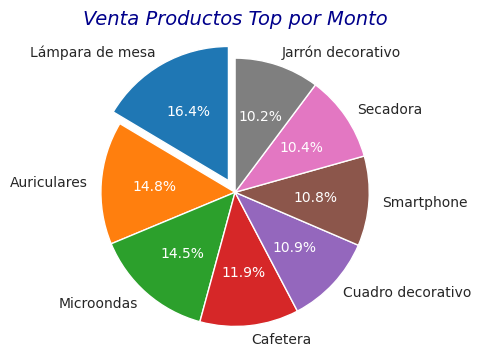

In [84]:
# @title
# PRODUCTOS TOP POR MONTO
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de torta
plt.figure(figsize=(4, 4))
sns.set_style("whitegrid")
explode = [0.1, 0,0,0,0,0,0,0]

# ['prod_gener'] = "producto" en la otra tabla
wedges, texts, autotexts = plt.pie(prod_top_monto['valor_venta'], labels=prod_top_monto['producto'],
                                   autopct='%1.1f%%', explode=explode, startangle=90)

# Cambiar los atributos del título
plt.title('Venta Productos Top por Monto', fontsize=14, color='darkblue', style='italic')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Cambiar el color de los porcentajes a blanco
for autotext in autotexts:
    autotext.set_color('white')

plt.show()


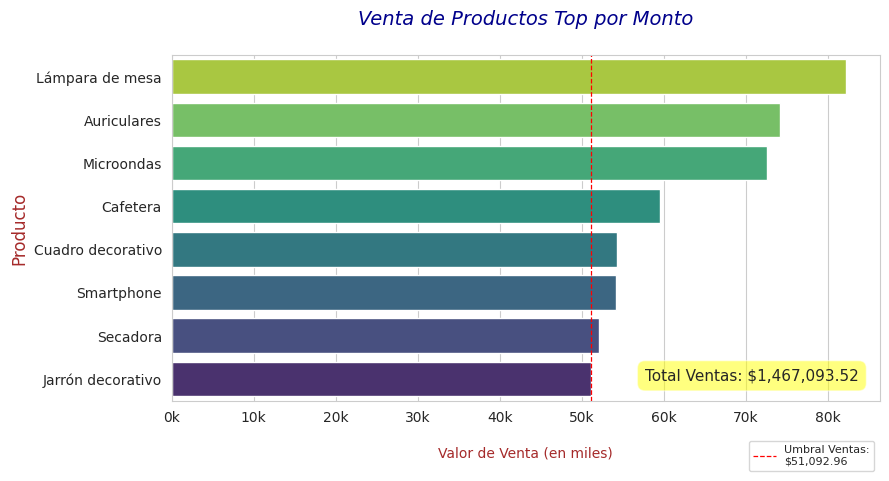

In [85]:

# @title
# PRODUCTOS TOP POR MONTO
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Crear el gráfico de barras horizontal
plt.figure(figsize=(9, 5))
sns.barplot(x='valor_venta', y='producto', data=prod_top_monto, palette='viridis_r', hue='producto')

# Cambiar los atributos del título
plt.title('Venta de Productos Top por Monto\n', fontsize=14, color='darkblue', style='italic')
plt.xlabel('\nValor de Venta (en miles)',fontsize=10, color="brown")
plt.ylabel('Producto', fontsize=12, color="brown")

# Definir una función de formato para el eje x
def thousands_formatter(x, pos):
    return f'{int(x/1000)}k'

# Aplicar el formateador al eje x
formatter = mticker.FuncFormatter(thousands_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

# Añadir una anotación para el total de ventas en la parte inferior
plt.text(0.97, 0.05, f'Total Ventas: ${ventas_totales:,.2f}', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# Agregar un marcador para umbral_ventas en el eje X
plt.axvline(x=umbral_ventas, color='red', linestyle='--', linewidth=0.9,
            label=f'Umbral Ventas:\n${umbral_ventas:,.2f}')
plt.legend(loc='lower right', bbox_to_anchor=(1.0, -0.22),fontsize=8)

plt.tight_layout() # Ajustar el diseño para evitar solapamientos
plt.show()



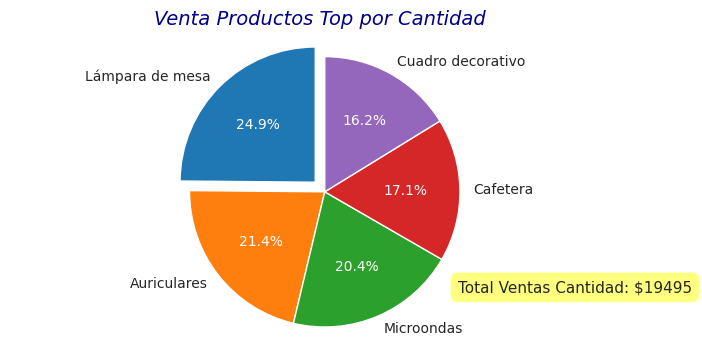

In [111]:
# @title
# PRODUCTOS TOP POR CANTIDAD UNIDADES VENDIDAS
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de torta
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")

# The original 'explode' variable from a previous cell had 8 elements.
# 'prod_top_cant' has 7 products (check prod_top_cant.shape[0] or len(prod_top_cant)).
# So, 'explode' must have a length of 7 to match.
explode = [0.1] + [0] * (len(prod_top_cant) - 1)

wedges, texts, autotexts = plt.pie(prod_top_cant['cant_vend'], labels=prod_top_cant['producto'], autopct='%1.1f%%', explode=explode, startangle=90)

# Cambiar los atributos del título
plt.title('Venta Productos Top por Cantidad', fontsize=14, color='darkblue', style='italic')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Cambiar el color de los porcentajes a blanco
for autotext in autotexts:
    autotext.set_color('white')

# Añadir una anotación para el total de unid vendidas en la parte inferior
plt.text(1.1, 0.15, f'Total Ventas Cantidad: ${total_ventas_cant:.0f}', transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.show()

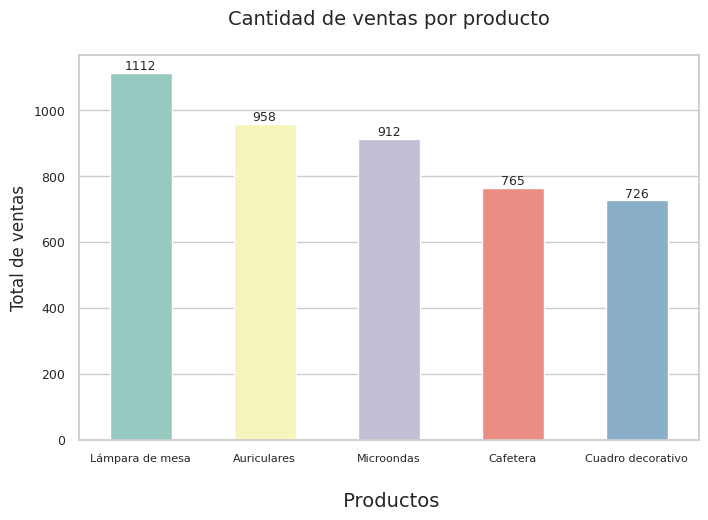

In [115]:
# @title
# Estilo y paleta
sns.set_theme(               # set_theme combina estilo + contexto + paleta
    style="whitegrid",       # opciones: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'
    context="notebook",          # escala general: 'paper', 'notebook', 'talk', 'poster'
    palette="Set3"           # paleta de colores base: "deep", "muted", "pastel" / Set1, Set2, Set3
)

# Ajustamos tamaño del lienzo
plt.figure(figsize=(8,5))

# Crear el barplot
ax = sns.barplot(data=prod_top_cant, x='producto', y='cant_vend', hue='producto', width=0.5)

# Agregar etiquetas arriba de las barras
for i, valor in enumerate(prod_top_cant['cant_vend']):
    str_valor = f"{valor:.0f}"
    ax.text(
        i,                      # posición x de la etiqueta
        valor + 10,             # posición y (ligeramente arriba de la barra)
        str_valor,              # texto
        ha='center', fontsize=9
    )

# Ticks (valores de eje)
plt.tick_params(axis='y', labelsize=9)
plt.tick_params(axis='x', labelsize=8)

# Ajustes de título y ejes
plt.title('Cantidad de ventas por producto\n', fontsize=14)
plt.xlabel('\n Productos', fontsize=14)
plt.ylabel('Total de ventas')
# plt.legend(loc='upper right', fontsize=10) # Removed this line as seaborn handles the legend with hue

# plt.tight_layout() # ajuste automatico
plt.show()


<!-- Inserta aquí tus comentarios o notas. Por ejemplo: -->

### Observaciones Importantes

*   Hasta ahora tanto por monto como por cantidad de unidades vendias el ranking es:

In [117]:
# @title
ranking_ventas = pd.merge(prod_top_monto, prod_top_cant, on="producto", how="left")
ranking_ventas.head()

,producto,valor_venta,cant_vend
0,Lámpara de mesa,82276.38,1112.0
1,Auriculares,74175.58,958.0
2,Microondas,72562.89,912.0
3,Cafetera,59607.31,765.0
4,Cuadro decorativo,54297.60,726.0


## Agregación
### Resumir las ventas por categoría de producto y analizar los ingresos generados.

In [118]:
df_ventas_final.columns

Index(['id_venta', 'producto', 'precio_unit', 'cantidad', 'fecha_venta',
       'categoria', 'valor_venta'],
      dtype='object')

In [119]:
# Agrupamos por categoria y agregamos el total valor_venta por categoria
# (solo son 3 categorías )
ventas_categoria = df_ventas_final.groupby("categoria", as_index=False)["valor_venta"].sum()
ventas_categoria.head()

,categoria,valor_venta
0,Decoración,479216.09
1,Electrodomésticos,505299.63
2,Electrónica,482577.80


In [120]:
# Ordenar y mostrar los resultados
ventas_categoria.sort_values(by="valor_venta", ascending=False, inplace=True)
ventas_categoria

,categoria,valor_venta
1,Electrodomésticos,505299.63
2,Electrónica,482577.80
0,Decoración,479216.09


### Ventas por Categoria

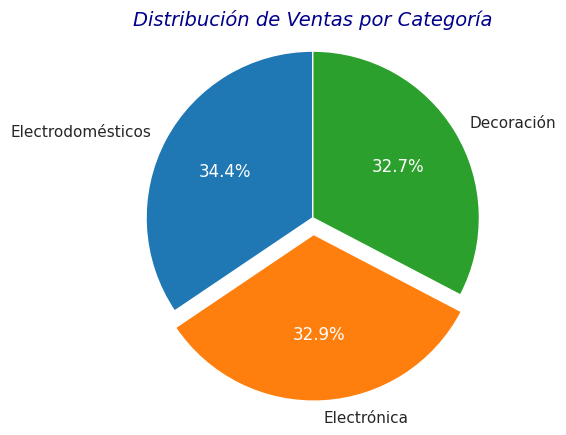

In [149]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de torta
plt.figure(figsize=(5, 5))

sns.set_style("whitegrid")
sns.set_palette('tab10') # "tab10")

explode = [0, 0.1, 0]
wedges, texts, autotexts = plt.pie(ventas_categoria['valor_venta'],
          labels=ventas_categoria['categoria'], autopct='%1.1f%%', explode=explode, startangle=90)

# Cambiar los atributos del título
plt.title('Distribución de Ventas por Categoría', fontsize=14, color='darkblue', style='italic')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Cambiar el color de los porcentajes a blanco
for autotext in autotexts:
    autotext.set_color('white')

plt.show()


Observaciones:

A pesar de estar equilibradas las ventas, se puede ver que la categoría 'Electrodomésticos' representa una mayor parte de las ventas.

.  


## Integración de datos
Actividad 4 - Combinar los sets de datos de ventas y marketing para obtener una visión más amplia de las tendencias.

In [150]:
df_ventas_final.head(2)

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5


In [ ]:
df_ventas_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venta     2998 non-null   int64         
 1   producto     2998 non-null   object        
 2   precio_unit  2998 non-null   float64       
 3   cantidad     2998 non-null   int64         
 4   fecha_venta  2998 non-null   datetime64[ns]
 5   categoria    2998 non-null   object        
 6   valor_venta  2998 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 187.4+ KB


In [230]:
# renombrar costo => costo_mrkt y ojo con las cantidades !!!
# df_marketing.info()
df_marketing_final.rename(columns={"costo": "costo_mrkt"}, inplace=True)
df_marketing.rename(columns={"costo": "costo_mrkt"}, inplace=True)

df_marketing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo_mrkt    90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


In [ ]:
df_marketing.head()

In [152]:
# Vemos la cantidad de productos unicos en ventas
df_ventas_final["producto"].nunique()


30

In [153]:
# Vemos la cantidad de productos unicos en marketing
df_marketing["producto"].nunique()

30

In [ ]:
# Listamos los registros de ventas ordenados por producto, forma ascendente
df_ventas_final.sort_values(by="producto", ascending=True )


In [168]:
df_ventas_final.head()


,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84



###**Unimos los dataframes ventas con marketing**   

**NOTA After Class 15**

Para quienes quieran analizar mejor el impacto de las campañas de marketing en las ventas, les sugiero agregar estas dos líneas de código, primero para hacer un backup del dataframe y luego filtrar y seleccionar sólo un canal de marketing.  

Esto lo sugiero porque para un mismo producto hay 3 campañas en canales diferentes, pero realizadas en diferentes períodos del año, por lo que siempre hay una venta de un producto con y sin campaña. Esto es porque la tabla "marketing" debería tener una integridad referencial con el id_venta pero es una cuestión de diseño, y debemos trabajar con los datos que tenemos.

In [166]:
df_marketing_final.head()

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05


In [157]:
# Hacer un backup de dataframe de marketing
df_marketin_backup = df_marketing.copy()


In [169]:
# Filtrar solo un canal de marketing
df_marketing_rs = df_marketing.query("canal == 'RRSS'")

In [170]:
# Hacemos el merge entre marketing y ventas por columna producto
ventas_marketing_rs = pd.merge(df_ventas_final, df_marketing_rs, on="producto", how="left")
print("Cantidad de registros: ", len(ventas_marketing_rs))


Cantidad de registros:  2998


In [171]:
ventas_marketing_rs.columns

Index(['id_venta', 'producto', 'precio_unit', 'cantidad', 'fecha_venta',
       'categoria', 'valor_venta', 'id_campanha', 'canal', 'costo_mrkt',
       'fecha_inicio', 'fecha_fin'],
      dtype='object')

In [ ]:
# Visualizemos algunos registros luego del merge (ordenados por producto, id_venta)
ventas_marketing_rs[["id_venta","producto",  "canal", "cantidad", "precio_unit","valor_venta","costo_mrkt", "fecha_venta", "fecha_inicio","fecha_fin"]].sort_values(by=["producto", "id_venta"], ascending=True).head(6)


In [174]:
# Visualizamos algunos registros, pero ordenamos por valor_venta
ventas_marketing_rs[["id_venta","producto", "valor_venta", "canal", "costo_mrkt", "fecha_venta", "fecha_inicio","fecha_fin"]].sort_values(by=["valor_venta"], ascending=False).head(6)


,id_venta,producto,valor_venta,canal,costo_mrkt,fecha_venta,fecha_inicio,fecha_fin
548,2063,Smartphone,1488.12,RRSS,6.37,2024-03-05,2024-03-29,2024-05-16
875,1109,Batidora,1485.96,RRSS,4.52,2024-04-11,2024-11-01,2024-12-08
846,2373,Smartphone,1483.20,RRSS,6.37,2024-04-07,2024-03-29,2024-05-16
2308,2703,Smartphone,1480.80,RRSS,6.37,2024-10-03,2024-03-29,2024-05-16
511,1569,Batidora,1464.24,RRSS,4.52,2024-02-29,2024-11-01,2024-12-08
263,1481,Freidora eléctrica,1461.24,RRSS,5.27,2024-01-31,2024-12-29,2025-01-21


Luego del merge encontramos:  


*    Aparecen ventas duplicadas, por ejemplo los primeros 3 registros con id_venta 2063, dado que ese producto tuvo 3 campañas de marketing, pero para este caso fue vendido fuera del período de marketing.

*    Y ver el caso de los últimos 3 registros con id_venta 1109, dos de ellos dentro y uno fuera del período

Por ello, vamos a generar dos nuevos dataframes, uno con aquellas ventas dentro del período de marketing, y otro fuera del período


### **Ventas dentro de la campaña**


In [175]:
# filtramos solo aquellos productos que se hayan vendido dentro de la campaña de marketing
ventas_con_marketing = ventas_marketing_rs.query("fecha_venta >= fecha_inicio & fecha_venta <= fecha_fin")
print("Cantidad de registros dentro de la campaña: ", len(ventas_con_marketing))


Cantidad de registros dentro de la campaña:  264


In [177]:
# Visualicemos algunos de los registros de ventas durante la campaña de marketing
ventas_con_marketing[["id_venta","producto", "valor_venta", "canal", "costo_mrkt", "fecha_venta", "fecha_inicio","fecha_fin"]].sort_values(by=["id_venta"], ascending=True).head(6)


,id_venta,producto,valor_venta,canal,costo_mrkt,fecha_venta,fecha_inicio,fecha_fin
2210,3,Espejo decorativo,51.32,RRSS,4.75,2024-09-22,2024-08-28,2024-10-17
2339,6,Cortinas,647.57,RRSS,5.22,2024-10-08,2024-09-16,2024-10-15
2415,9,Candelabro,256.90,RRSS,5.32,2024-10-19,2024-10-08,2024-11-16
1133,14,Jarrón decorativo,148.85,RRSS,4.65,2024-05-09,2024-05-09,2024-06-13
2912,15,Alfombra,286.62,RRSS,5.82,2024-12-20,2024-11-27,2025-01-08
1121,22,Cuadro decorativo,734.16,RRSS,5.27,2024-05-08,2024-04-27,2024-06-04


In [178]:
# Como vemos algunos duplicados, listemos solo esos
ventas_con_marketing_duplicados = ventas_con_marketing[ventas_con_marketing.duplicated(subset="id_venta",keep=False)]
ventas_con_marketing_duplicados[["id_venta","producto", "valor_venta", "canal", "costo_mrkt", "fecha_venta", "fecha_inicio","fecha_fin"]].sort_values(by=["producto", "id_venta"], ascending=True).head(6)


,id_venta,producto,valor_venta,canal,costo_mrkt,fecha_venta,fecha_inicio,fecha_fin


Los registros con id_venta duplicados nos impiden agrupar directamente por producto, debemos antes agrupar por [id_venta, producto] quedarnos con el primer valor_venta y hacer la suma de los costos de marketing.
Luego si agrupamos por producto, para saber el monto total de venta para cada uno.

In [179]:
# Entonces agrupamos primero por id_venta y producto
# de esa particion, nos quedamos con la primera venta y la suma de los costos de marketing
ventas_con_marketing_agg1 = ventas_con_marketing.groupby(["id_venta","producto"], as_index=False).agg(
    valor_venta=("valor_venta", "first"),
    costo_agg=("costo_mrkt", "sum")
)

print("Cantidad de registros con id_venta únicos: ", len(ventas_con_marketing_agg1))



Cantidad de registros con id_venta únicos:  264


In [180]:
# Verificamos la consistencia de los montos, ventas y costos de marketing
ventas_con_marketing_agg1[["id_venta","producto", "valor_venta", "costo_agg"]].sort_values(by=["id_venta"], ascending=True).head(6)


,id_venta,producto,valor_venta,costo_agg
0,3,Espejo decorativo,51.32,4.75
1,6,Cortinas,647.57,5.22
2,9,Candelabro,256.90,5.32
3,14,Jarrón decorativo,148.85,4.65
4,15,Alfombra,286.62,5.82
5,22,Cuadro decorativo,734.16,5.27


In [181]:
# En la segunda agregacion, agrupamos solo por producto,
ventas_con_marketing_agg2 = ventas_con_marketing_agg1.groupby(["producto"], as_index=False).agg(
    ventas_producto_cm=("valor_venta", "sum"),
    costo_marketing=("costo_agg", "sum")
)

# Agregamos otra columna con la ganancia
ventas_con_marketing_agg2["ganancia_producto_cm"]= ventas_con_marketing_agg2["ventas_producto_cm"]-ventas_con_marketing_agg2["costo_marketing"]

# Finalmente, ordenamos y guardamos en el dataframe final
ventas_con_marketing_final = ventas_con_marketing_agg2.sort_values(by=["ganancia_producto_cm"], ascending=False)


In [184]:
# Repetimos la agrupación pero ahora por mes,

ventas_con_marketing["mes"] = ventas_con_marketing["fecha_venta"].dt.month
ventas_con_marketing = ventas_con_marketing.sort_values("id_venta")

ventas_con_marketing_agg3 = ventas_con_marketing.groupby(["id_venta","mes"], as_index=False).agg(
    valor_venta=("valor_venta", "first"),
    costo_agg=("costo_mrkt", "sum")
)

ventas_con_marketing_agg4 = ventas_con_marketing_agg3.groupby(["mes"], as_index=False).agg(
    ventas_producto_cm=("valor_venta", "sum"),
    costo_marketing=("costo_agg", "sum")
)

# Agregamos otra columna con la ganancia
ventas_con_marketing_agg4["ganancia_producto_cm"] = ventas_con_marketing_agg4["ventas_producto_cm"]- ventas_con_marketing_agg4["costo_marketing"]

# Finalmente, ordenamos y guardamos en el dataframe final
ventas_con_marketing_mes = ventas_con_marketing_agg4.sort_values(by=["mes"], ascending=True)


In [185]:
# Dataframe resultante
ventas_con_marketing_mes.head(12)


,mes,ventas_producto_cm,costo_marketing,ganancia_producto_cm
0,3,2008.90,13.17,1995.73
1,4,7416.19,80.03,7336.16
2,5,17884.22,192.51,17691.71
3,6,12423.95,111.54,12312.41
4,7,11127.71,134.24,10993.47
5,8,23360.59,244.04,23116.55
6,9,12444.95,179.90,12265.05
7,10,20639.83,199.42,20440.41
8,11,8299.16,86.86,8212.30
9,12,9844.02,99.73,9744.29


## Ventas fuera de la campaña de marketing


In [186]:
# filtramos solo aquellos productos que se hayan vendido fuera de la campaña
ventas_sin_marketing = ventas_marketing_rs.query("(fecha_venta < fecha_inicio) | (fecha_venta > fecha_fin)")
print("Cantidad de registros fuera de la campaña: ", len(ventas_sin_marketing))


Cantidad de registros fuera de la campaña:  2734


In [187]:
ventas_sin_marketing[["id_venta","producto", "valor_venta","canal", "fecha_venta", "fecha_inicio","fecha_fin"]].sort_values(by=["id_venta","producto"], ascending=True).head(6)


,id_venta,producto,valor_venta,canal,fecha_venta,fecha_inicio,fecha_fin
931,1,Lámpara de mesa,658.00,RRSS,2024-04-17,2024-05-30,2024-06-29
486,2,Cuadro decorativo,318.36,RRSS,2024-02-27,2024-04-27,2024-06-04
2520,4,Jarrón decorativo,769.44,RRSS,2024-11-01,2024-05-09,2024-06-13
2525,5,Alfombra,280.40,RRSS,2024-11-02,2024-11-27,2025-01-08
2171,7,Elementos de cerámica,123.38,RRSS,2024-09-16,2024-06-26,2024-07-15
528,8,Rincón de plantas,491.68,RRSS,2024-03-03,2024-08-03,2024-08-18


In [188]:
# Aquí también hay id_venta duplicados, así que procedemos igual que antes, agrupando
# primero por id_venta y producto y luego solo por producto
ventas_sin_marketing_agg1 = ventas_sin_marketing.groupby(["id_venta", "producto"],
          as_index=False).agg( valor_venta=("valor_venta", "first")
)
print(len(ventas_sin_marketing_agg1))
print(len(df_ventas))

ventas_sin_marketing_agg2 = ventas_sin_marketing_agg1.groupby(["producto"],
          as_index=False).agg(ventas_producto_sm=("valor_venta", "sum")
)

# Ordenamos y guardamos en el dataframe final
ventas_sin_marketing_final = ventas_sin_marketing_agg2[["producto",
    "ventas_producto_sm"]].sort_values(by=["ventas_producto_sm"], ascending=False)


2734
2998


In [191]:
# Repetimos, pero ahora nos enfocamos en el mes

ventas_sin_marketing["mes"]= ventas_sin_marketing["fecha_venta"].dt.month
ventas_sin_marketing = ventas_sin_marketing.sort_values("id_venta")

ventas_sin_marketing_agg3 = ventas_sin_marketing.groupby(["id_venta", "mes"],
          as_index=False).agg( valor_venta=("valor_venta", "first")
)

ventas_sin_marketing_agg4 = ventas_sin_marketing_agg3.groupby(["mes"],
    as_index=False).agg( ventas_producto_sm=("valor_venta", "sum")
)

# Ordenamos y guardamos en el dataframe final
ventas_sin_marketing_mes = ventas_sin_marketing_agg4[["mes",
                "ventas_producto_sm"]].sort_values(by=["mes"], ascending=True)


In [190]:
ventas_sin_marketing_mes.head(12)


,mes,ventas_producto_sm
0,1,129604.99
1,2,118672.44
2,3,134770.25
3,4,121014.50
4,5,125843.03
5,6,96056.22
6,7,105102.26
7,8,96319.56
8,9,103342.90
9,10,91477.30


## Graficamos ventas y costos de marketing apilado

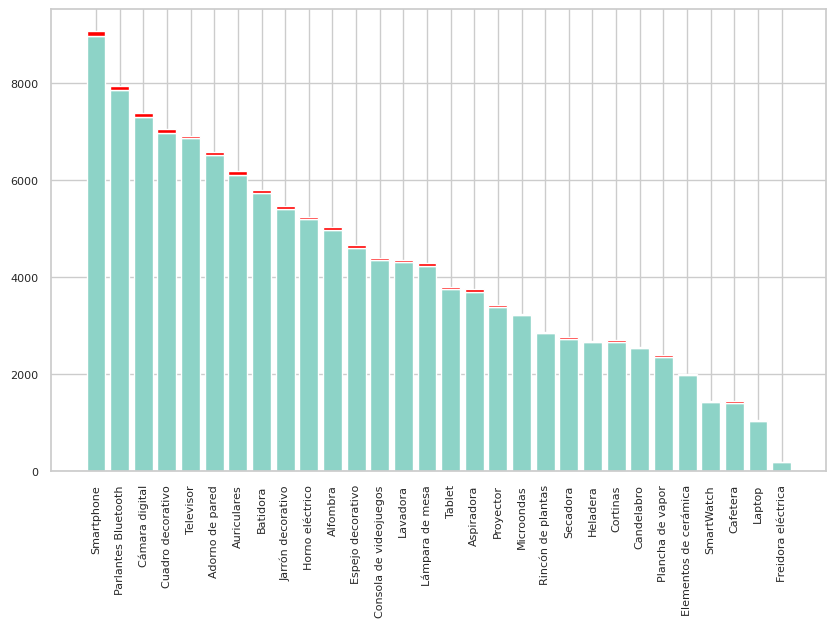

['#8dd3c7', '#ff0000', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5', '#ffed6f']


In [220]:
import matplotlib.pyplot as plt
import seaborn as sns
# Crear un gráfico de barras apilado para comparar valor_venta y costo por producto

# Estilos
plt.figure(figsize=(10,6))

#print(len(set3_hex_colors), set3_hex_colors)
#set3_colors = ['#8dd3c7', '#000000', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#d9d9d9', '#bc80bd', '#ccebc5', '#ffed6f']
set3_colors = sns.color_palette('Set3').as_hex()
set3_colors[1] = "#ff0000"

sns.set_theme(
    style="whitegrid",
    palette=sns.color_palette(set3_colors),
    context="notebook")

# Primer nivel (abajo)
plt.bar(ventas_con_marketing_final["producto"], ventas_con_marketing_final["ventas_producto_cm"],
        label="Ventas")

# Segundo nivel (arriba)
plt.bar(ventas_con_marketing_final["producto"], ventas_con_marketing_final["costo_marketing"],
        bottom=ventas_con_marketing_final["ventas_producto_cm"],
        label="Costo Marketing")


plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.show()


## **A partir de aca seguimos con lo viejo**

In [ ]:
# Listamos los registros de marketing ordenados por producto, forma ascendente
#df_marketing2 = df_marketing.sort_values(by="producto", ascending=True)
df_marketing.sort_values(by=["producto","canal"])

df_marketing.head(6)

,id_campanha,producto,canal,costo_mrkt,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05
5,85,SmartWatch,TV,5.07,2024-04-01,2024-05-05


In [ ]:
# Para evitar duplicados, habria que agrupar marketing antes de hacer el merge
# (a costa de perder la fecha)
df_marketing_avg = df_marketing.groupby(["producto"], as_index=False)["costo_mrkt"].mean()
df_marketing_avg

In [ ]:
# Unir los datasets ventas y marketing por columna 'producto'

# Aqui tenemos dos caminos, unir ventas con df_marketing que tiene duplicados
# met 1
ventas_marketing1 = pd.merge(df_ventas_final, df_marketing, on="producto", how="left")

# unir df_ventas con df_marketing_avg que no tiene duplicados, pero no tiene fechas
# met 2
ventas_marketing_avg = pd.merge(df_ventas_final, df_marketing_avg, on="producto", how="inner")


In [ ]:
ventas_marketing1.info()

In [ ]:
ventas_marketing_avg.info()

In [ ]:
# Verificar coincidencias (muestra)
ventas_marketing1.sort_values(by=["producto", "precio_unit"], ascending=True)
ventas_marketing1.head(6)

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta,id_campanha,canal,costo_mrkt,fecha_inicio,fecha_fin
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,1,RRSS,5.27,2024-04-27,2024-06-04
1,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,31,Email,5.28,2024-08-15,2024-09-12
2,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7,61,TV,5.30,2024-11-05,2024-12-23
3,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5,32,Email,5.54,2024-03-28,2024-04-20
4,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5,2,RRSS,5.88,2024-05-30,2024-06-29
5,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5,62,TV,4.51,2024-08-26,2024-10-07


In [ ]:
# Nota1: si unieron ventas con marketing, obtienen 8994 registros
# Nota2: si unieron ventas con marketing_avg obtienen 2998 registros



### Analizamos el impacto de la campaña

In [ ]:
# Nos quedamos solo con los registros de ventas durante la campaña de marketing
ganancias_marketing = ventas_marketing1.query("fecha_venta > fecha_inicio & fecha_venta < fecha_fin")

# Nota: si trabajan con el DF marketing1 pueden aplicar el filtro,
# si trabajan con dataframe marketing_avg, al no tener fecha, no apliquen el filtro.


# Seleccionamos solo los campos que nos interesan: "producto", "valor_venta", "costo"
ganancias_marketing = ganancias_marketing[["producto", "valor_venta", "costo_mrkt","cantidad"]]
ganancias_marketing.sort_values(by="producto", ascending=True)
ganancias_marketing.head(6)


,producto,valor_venta,costo_mrkt,cantidad
2091,Adorno de pared,553.91,4.81,7
2124,Adorno de pared,579.54,4.81,6
2160,Adorno de pared,286.68,4.81,4
2256,Adorno de pared,831.20,4.81,8
2286,Lámpara de mesa,44.88,5.54,1
2298,Tablet,394.24,3.40,11


In [ ]:
# Agrupamos por producto y hacemos una agregación por "valor de venta" y "costo"
ganancias_marketing = ganancias_marketing.groupby("producto")[["valor_venta","costo_mrkt","cantidad"]].sum()
ganancias_marketing

## ACA hay un ERROR ???   
por qué no se multiplica:  

cantidad vendida x costo_mrkt (que es unitario)

In [ ]:

# Generamos una nueva columna con la diferencia entre lo vendido y lo invertido en la campaña

ganancias_marketing["ganancia_neta"] = ganancias_marketing['valor_venta'] -(ganancias_marketing['costo_mrkt'] * ganancias_marketing['cantidad'])

ganancias_marketing = ganancias_marketing.sort_values(by="ganancia_neta", ascending=False)

ganancias_marketing.head()


,valor_venta,costo_mrkt,cantidad,ganancia_neta
producto,,,,
Heladera,8233.36,60.12,106,1860.64
Consola de videojuegos,7785.49,68.69,99,985.18
Candelabro,5700.53,63.08,78,780.29
Lavadora,8738.74,70.89,113,728.17
Rincón de plantas,8098.52,77.22,96,685.40


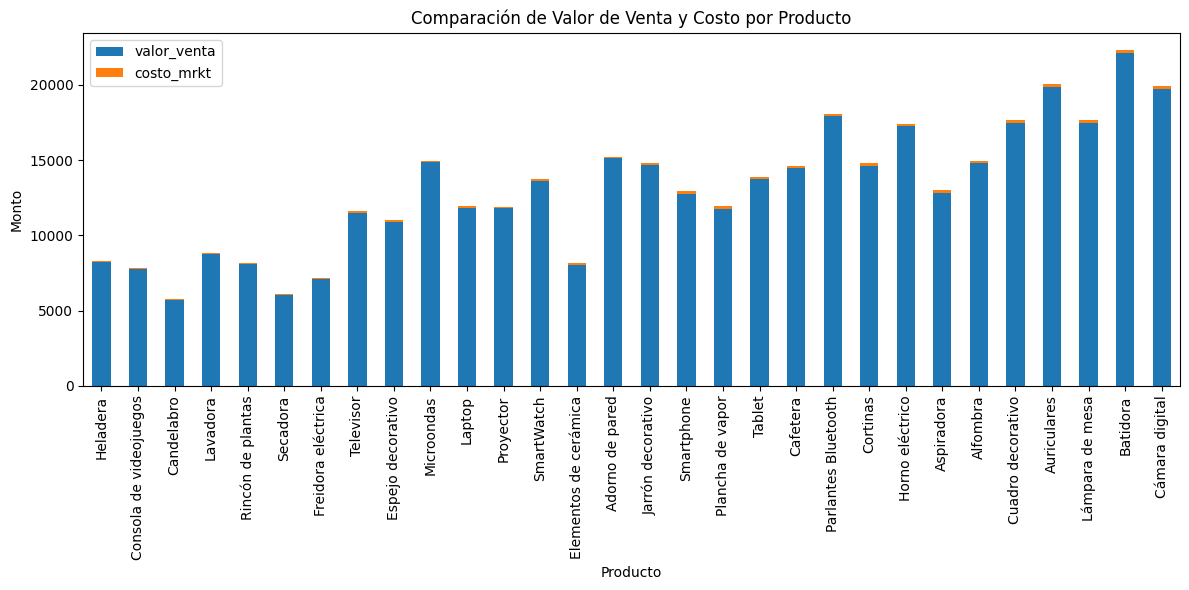

In [ ]:
#
# Crear un gráfico de barras apilado para comparar valor_venta y costo por producto

ganancias_marketing[["valor_venta", "costo_mrkt"]].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Comparación de Valor de Venta y Costo por Producto")
plt.xlabel("Producto")
plt.ylabel("Monto")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# **Solución al problema de los duplicados**

In [ ]:
# Hacemos el merge entre marketing y ventas por columna producto
marketing_ventas = pd.merge(df_marketing, df_ventas_final, on="producto", how="inner")
marketing_ventas.sort_values(by="producto", ascending=True)
marketing_ventas.head(6)

,id_campanha,producto,canal,costo_mrkt,fecha_inicio,fecha_fin,id_venta,precio_unit,cantidad,fecha_venta,categoria,valor_venta
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,630,71.99,9,2024-01-04,Decoración,647.91
1,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,560,57.62,6,2024-01-07,Decoración,345.72
2,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,830,67.23,10,2024-01-10,Decoración,672.30
3,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,20,90.21,2,2024-01-14,Decoración,180.42
4,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,260,101.48,9,2024-01-15,Decoración,913.32
5,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,430,81.76,5,2024-01-18,Decoración,408.80


In [ ]:
# filtramos solo aquellos productos que se hayan vendido dentro de la campaña
marketing_ventas_pp1 = marketing_ventas.query("fecha_venta > fecha_inicio & fecha_venta < fecha_fin")
marketing_ventas_pp1.head(6)

,id_campanha,producto,canal,costo_mrkt,fecha_inicio,fecha_fin,id_venta,precio_unit,cantidad,fecha_venta,categoria,valor_venta
24,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,780,79.13,7,2024-03-21,Decoración,553.91
25,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,270,96.59,6,2024-03-22,Decoración,579.54
26,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,210,71.67,4,2024-03-24,Decoración,286.68
27,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,730,103.90,8,2024-03-28,Decoración,831.20
28,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,390,87.52,8,2024-04-01,Decoración,700.16
29,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,570,64.18,7,2024-04-03,Decoración,449.26


In [ ]:
# Calculamos el total_ventas por producto haciendo valor_venta * cantidad
marketing_ventas_pp2 = marketing_ventas_pp1.copy() # para eliminar la advertencia
#marketing_ventas_pp2.info()

marketing_ventas_pp2["total_venta"] = (
    marketing_ventas_pp2["valor_venta"] * marketing_ventas_pp2["cantidad"]
)
marketing_ventas_pp2.head(6)

,id_campanha,producto,canal,costo_mrkt,fecha_inicio,fecha_fin,id_venta,precio_unit,cantidad,fecha_venta,categoria,valor_venta,total_venta
24,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,780,79.13,7,2024-03-21,Decoración,553.91,3877.37
25,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,270,96.59,6,2024-03-22,Decoración,579.54,3477.24
26,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,210,71.67,4,2024-03-24,Decoración,286.68,1146.72
27,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,730,103.90,8,2024-03-28,Decoración,831.20,6649.60
28,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,390,87.52,8,2024-04-01,Decoración,700.16,5601.28
29,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,570,64.18,7,2024-04-03,Decoración,449.26,3144.82


In [ ]:
# Agrupamos el dataframe por producto  usando agg

# Agregar total_venta como el promedio, elimina el impacto de los datos duplicados
# Y seguimos agregando costo_mrkt como la suma de lo invertido en cada canal
ganancias_marketing = marketing_ventas_pp2.groupby("producto").agg(
    {
        "total_venta": "mean",
        "costo_mrkt": "sum",
    }
)
#ganancias_marketing

In [ ]:
# A partir de venta_total y costo, calculamos la ganancia obtenida
ganancias_marketing["ganancia"] = ganancias_marketing["total_venta"]- ganancias_marketing["costo_mrkt"]
ganancias_marketing = ganancias_marketing.sort_values(by="ganancia", ascending=False)
ganancias_marketing.head(3)


,total_venta,costo_mrkt,ganancia
producto,,,
Microondas,6164.674783,104.89,6059.784783
Heladera,5786.587143,60.12,5726.467143
Cafetera,5388.738000,160.84,5227.898000


In [ ]:
# Creamos un gráfico de barras apilado para comparar valor_venta y costo por producto
ganancias_marketing[["total_venta", "costo_mrkt"]].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Comparación de Valor de Venta y Costo por Producto")
plt.xlabel("Producto")
plt.ylabel("Monto")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ==========================================================

# Entrega Final

# Etapa 3 - Análisis de Datos

Objetivo: Realizar análisis estadístico y exploratorio sobre los datos procesados.
sobre:
* df_ventas
* df_marketing

## 1 - Estadística Descriptiva

En la Etapa 2 - Limpieza de datos, obtuvimos los dataframes:

* df_ventas
* df_marketing

Usamos el método describe para obtener un resumen de las:
* Medidas de posición
* Medidas de dispersión o variabilidad

In [ ]:
# Dataframe ventas
df_ventas_final[["precio_unit", "cantidad", "valor_venta"]].describe()
# df_ventas.describe()

In [223]:
df_marketing.head()

,id_campanha,producto,canal,costo_mrkt,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05


In [ ]:
df_marketing.groupby("canal")["costo_mrkt"].describe()

## 2 - EDA (Análisis Exploratorio de Datos)

Realizar un análisis exploratorio utilizando visualizaciones para identificar patrones y tendencias en las ventas.

### Gráficos histogramas

In [ ]:
# Histograma de precios

# Estilo y tamaños
sns.set_theme(style="darkgrid", palette="deep") # deep, muted, bright, Set1, Set2, Set3
plt.figure(figsize=(10, 6))

# Graficamos
sns.histplot(data=df_ventas_final, x="precio_unit", bins="auto", kde=True)

# Títulos y leyendas
plt.title("Histograma de Precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Histograma cantidades

# Estilo y tamaños
sns.set_theme(style="darkgrid", palette="deep") # deep, muted, bright, Set1, Set2, Set3
plt.figure(figsize=(10, 6))

# Graficamos
sns.histplot(data=df_ventas_final, x="cantidad", bins="auto", kde=True)

# Títulos y leyendas
plt.title("Histograma de Cantidades")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Histograma ventas_totales

# Estilo y tamaños
sns.set_theme(style="darkgrid", palette="deep") # deep, muted, bright, Set1, Set2, Set3
plt.figure(figsize=(10, 6))

# Graficamos
sns.histplot(data=df_ventas_final, x="valor_venta", bins="auto", kde=True)

# Títulos y leyendas
plt.title("Histograma de Ventas Totales")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
plt.show()


In [ ]:
# Histograma costo marketing

# Estilo y tamaños
sns.set_theme(style="darkgrid", palette="deep") # deep, muted, bright, Set1, Set2, Set3
plt.figure(figsize=(10, 6))

# Graficamos
sns.histplot(data=df_marketing, x="costo_mrkt", bins="auto", kde=True)

# Títulos y leyendas
plt.title("Histograma de Precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()


### Gráficos Boxplot

In [ ]:
# Boxplot Ventas

# Estilo y tamaños
sns.set_theme(style="darkgrid", palette="Set3") # deep, muted, bright, Set1, Set2, Set3
plt.figure(figsize=(12, 6)) #ancho x alto = resolucion

# Subplots, dividen al lienzo en partes
plt.subplot(1,3,1) # (1,3,1) => (1 fila, 3 columans, bloque 1)

# Subplot 1
sns.boxplot(data=df_ventas_final, y="precio_unit")
plt.title("Boxplot de Precios")
plt.ylabel("")

# Subplot 2
plt.subplot(1,3,2) # (1,3,2) => (1 fila, 3 columans, bloque 2)
sns.boxplot(data=df_ventas_final, y="valor_venta")
plt.title("Boxplot de Valor de venta")
plt.ylabel("")


# Subplot 3
plt.subplot(1,3,3) # (1,3,3) => (1 fila, 3 columans, bloque 3)
sns.boxplot(data=df_ventas_final, y="cantidad")
plt.title("Boxplot de Cantidad")
plt.ylabel("")

plt.show()

### Boxplot Ventas con valores estadísticos


In [ ]:
# @title
def rgb_to_hex(r, g, b):
    #--------------------------------------------------------------
    # Converts RGB values (0-255) to a hexadecimal color code.
    return f'#{r:02X}{g:02X}{b:02X}'


def hex_to_rgb(hex_color):
    #--------------------------------------------------------------
    # Converts a hexadecimal color code ( '#RRGGBB' or 'RRGGBB')
    # to an RGB tuple (R, G, B).
    # Remove '#' if present
    hex_color = hex_color.lstrip('#')

    # Handle 3-digit shorthand hex codes (e.g., #F00 -> #FF0000)
    if len(hex_color) == 3:
        hex_color = ''.join([c * 2 for c in hex_color])

    # Convert each two-character hex pair to its decimal equivalent
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return (r, g, b)

def float_RGB_to_int_RGB(float_rgb_tuple):
    #--------------------------------------------------------------------
    # Convierte una tupla RGB de float(0.0-1.0) a tupla RGB de int(0-255)
    return tuple(int(c * 255) for c in float_rgb_tuple)

def fRGB_to_iRGB(float_rgb_tuple):
    #---------------------------------
    # Convierte una tupla RGB de float(0.0-1.0) a tupla RGB de int(0-255)
    return tuple(int(c * 255) for c in float_rgb_tuple)

def int_RGB_to_float_RGB(r_int, g_int, b_int):
    # Converts integer RGB values (0-255) to float RGB values (0.0-1.0).
    # Returns: A tuple containing the float red, green, blue (0.0-1.0).
    r_float = r_int / 255.0
    g_float = g_int / 255.0
    b_float = b_int / 255.0
    return r_float, g_float, b_float


# Example usage:
#red_hex = rgb_to_hex(255, 0, 0)
#print(f"Red RGB to Hex: {red_hex}")

#blue_hex = rgb_to_hex(0, 0, 255)
#print(f"Blue RGB to Hex: {blue_hex}")


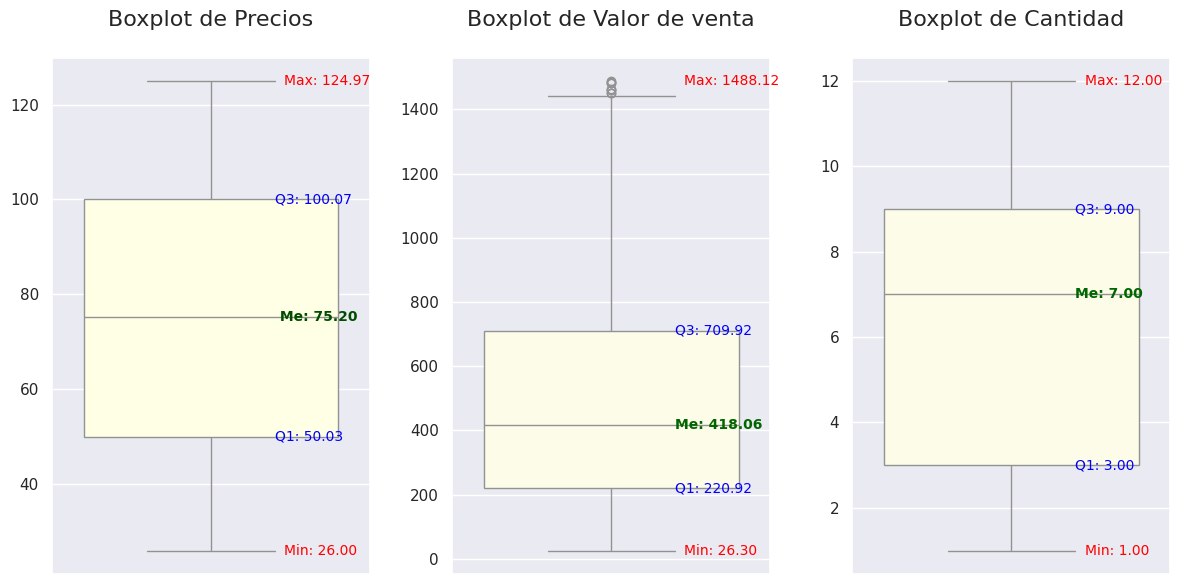

In [240]:
# Boxplot Ventas con valores estadísticos

# Estilo y tamaños de palette = # deep, muted, bright, Set1, Set2, Set3
# Obtener los colores de la paleta 'Pastel1'
pastel_colors = sns.color_palette("Pastel1")
pastel_colors[0] = (1.0, 1.0, 0.9019607843137255)

#custom_palette = sns.color_palette(["#FFFFe6", "#FFFFe6", "#FFFFe6","#FFFFe6",
#"#FFFFe6", "#FFFFe6", "#FFFFe6","#FFFFe6",])
# Por ejemplo, elegimos el segundo color de la paleta (indice 1)
# Se puede cambiar el indice para seleccionar otro color de la paleta
box_bgcolor = pastel_colors[0]

sns.set_theme(style="darkgrid", palette= pastel_colors)
print("\n")
plt.figure(figsize=(12, 6)) #ancho x alto = resolucion
# La paleta aquí controla los colores si no usas hue, o el borde si usas boxprops
# Usamos 'boxprops' para cambiar el color de relleno de las cajas
# sns.boxplot(data=df_marketing, x="canal", y="costo_mrkt",
#    boxprops=dict(facecolor=specific_box_color), # Aquí se aplica color a box
#    palette="Pastel1")

# Subplots, dividen al lienzo en partes
ax1 = plt.subplot(1,3,1) # (1 fila, 3 columans, bloque 1)

# Subplot 1: Precio
sns.boxplot(data=df_ventas_final, y="precio_unit", ax=ax1,boxprops=dict(facecolor=box_bgcolor))

plt.title("Boxplot de Precios\n", fontsize=16)
plt.ylabel("")
stats_precio = df_ventas_final["precio_unit"].describe()
ax1.text(0.23, stats_precio["max"], f'Max: {stats_precio["max"]:.2f}', verticalalignment='center', color='red',fontsize=10)
ax1.text(0.2, stats_precio["75%"], f'Q3: {stats_precio["75%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax1.text(0.2, stats_precio["50%"], f' Me: {stats_precio["50%"]:.2f}', verticalalignment='center', color='#004d00',fontsize=10,fontweight="bold")
ax1.text(0.2, stats_precio["25%"], f'Q1: {stats_precio["25%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax1.text(0.23, stats_precio["min"], f'Min: {stats_precio["min"]:.2f}', verticalalignment='center', color='red',fontsize=10)


ax2 = plt.subplot(1,3,2) # (1 fila, 3 columans, bloque 2)
# Subplot 2: Valor de venta
sns.boxplot(data=df_ventas_final, y="valor_venta", ax=ax2)
plt.title("Boxplot de Valor de venta\n", fontsize=16)
plt.ylabel("")
stats_valor_venta = df_ventas_final["valor_venta"].describe()
ax2.text(0.23, stats_valor_venta["max"], f'Max: {stats_valor_venta["max"]:.2f}', verticalalignment='center', color='red',fontsize=10)
ax2.text(0.2, stats_valor_venta["75%"], f'Q3: {stats_valor_venta["75%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax2.text(0.2, stats_valor_venta["50%"], f'Me: {stats_valor_venta["50%"]:.2f}', verticalalignment='center', color='#006600',fontsize=10,fontweight="bold")
ax2.text(0.2, stats_valor_venta["25%"], f'Q1: {stats_valor_venta["25%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax2.text(0.23, stats_valor_venta["min"], f'Min: {stats_valor_venta["min"]:.2f}', verticalalignment='center', color='red',fontsize=10)


ax3 = plt.subplot(1,3,3) # (1 fila, 3 columans, bloque 3)
# Subplot 3: Cantidad
sns.boxplot(data=df_ventas_final, y="cantidad", ax=ax3)
plt.title("Boxplot de Cantidad\n", fontsize=16)
plt.ylabel("")
stats_cantidad = df_ventas_final["cantidad"].describe()
ax3.text(0.23, stats_cantidad["max"], f'Max: {stats_cantidad["max"]:.2f}', verticalalignment='center', color='red',fontsize=10)
ax3.text(0.2, stats_cantidad["75%"], f'Q3: {stats_cantidad["75%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax3.text(0.2, stats_cantidad["50%"], f'Me: {stats_cantidad["50%"]:.2f}', verticalalignment='center', color='#006600',fontsize=10,fontweight="bold")
ax3.text(0.2, stats_cantidad["25%"], f'Q1: {stats_cantidad["25%"]:.2f}', verticalalignment='center', color='blue',fontsize=10)
ax3.text(0.23, stats_cantidad["min"], f'Min: {stats_cantidad["min"]:.2f}', verticalalignment='center', color='red',fontsize=10)

plt.tight_layout() # Ajusta el layout para evitar solapamientos
plt.show()


# BORRAR !!

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

tcolor = (1.0, 1.0, 0.8)
#print(f"mi_rgb = {fRGB_to_iRGB(tcolor)}")

myrgb = float_RGB_to_int_RGB(tcolor)
#print(f"mi hex= {rgb_to_hex(myrgb[0],myrgb[1],230)}")
#print(f"255,255,230= {int_RGB_to_float_RGB(255,255, 230)}")

# Obtener los colores de la paleta 'Pastel1'
pastel_colors = sns.color_palette("Pastel1")
pastel_colors[0] = (1.0, 1.0, 0.9019607843137255)

#-------------------------------------------------
# Get hex codes for the "pastel" palette
hex_codes = sns.color_palette( pastel_colors).as_hex()
#print(hex_codes)

# Por ejemplo, elegimos el segundo color de la paleta (índice 1)
# Puedes cambiar el índice para seleccionar otro color de la paleta
specific_box_color = pastel_colors[5]

#print(specific_box_color)

# Configurar el estilo de Seaborn
# Mantendremos el fondo del eje blanco o por defecto para resaltar el color de la caja
sns.set_theme(style="darkgrid", palette="Paired")

plt.figure(figsize=(12, 6))

# Graficamos el boxplot
# Usamos 'boxprops' para cambiar el color de relleno de las cajas
sns.boxplot(data=df_marketing, x="canal", y="costo_mrkt",
            boxprops=dict(facecolor=specific_box_color), # Aquí se aplica el color a las cajas
            palette="Pastel1", # La paleta aquí controla los colores si no usas hue, o el borde si usas boxprops
            hue="canal", legend=False)
# Título y subtítulo
plt.title("Distribución del Costo por Canal de Marketing (Cajas de color personalizado)", fontsize=16, pad=15)

plt.xlabel("Canales de Marketing", fontsize=12)
plt.ylabel("")

# Rotación y tamaño de labels del eje X
plt.xticks(rotation=45, fontsize=10)

plt.show()

In [ ]:
# @title
# Ejemplo de uso:
float_color = (1.0, 1.0, 0.8) # Un color amarillo claro de la paleta Pastel1
int_color = float_rgb_to_int_rgb(float_color)
print(f"Color flotante RGB: {float_color}")
print(f"Color entero RGB (0-255): {int_color}")

# Otro color de Pastel1
float_color_2 = (0.6352941176470588, 0.8117647058823529, 0.8901960784313725)
int_color_2 = float_rgb_to_int_rgb(float_color_2)
print(f"Color flotante RGB: {float_color_2}")
print(f"Color entero RGB (0-255): {int_color_2}")


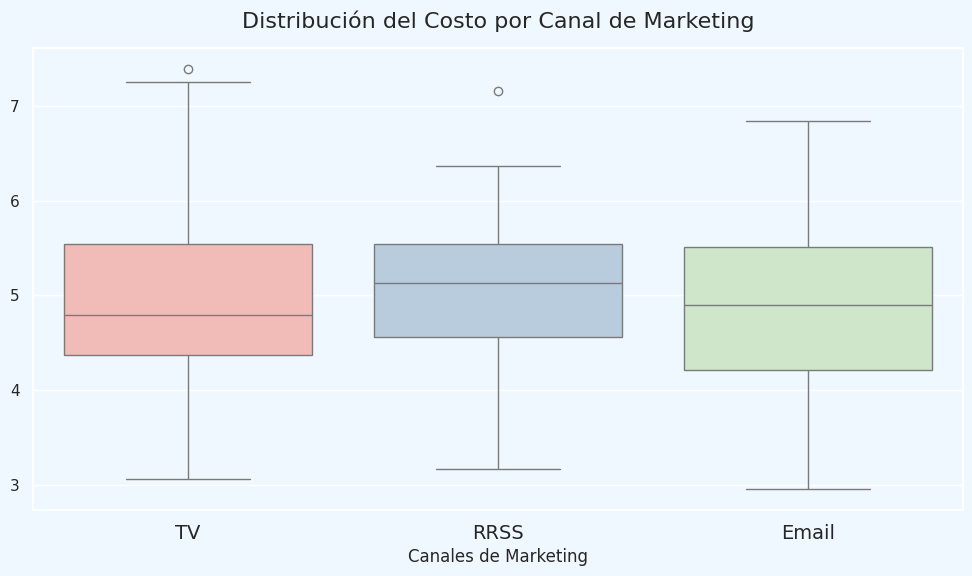

In [241]:
# Boxplot marketing

# Estilo y tamaños # deep, muted, bright, Set1, Set2, Set3 # 'F0F8FF' es un color azul claro
sns.set_theme(style="darkgrid", palette="Paired", rc={'axes.facecolor': '#F0F8FF', 'figure.facecolor': '#F0F8FF'})
plt.figure(figsize=(12, 6))

# Graficamos
sns.boxplot(data=df_marketing, x="canal", y="costo_mrkt", palette="Pastel1", hue="canal")
# sns.boxplot(data=df_marketing, y="costo_mrkt") # asi grafico costo para todos los canales

# Título y subtítulo
plt.title("Distribución del Costo por Canal de Marketing", fontsize=16, pad=15)

plt.xlabel("Canales de Marketing", fontsize=12)
plt.ylabel("")

# Rotación y tamaño de labels del eje X
plt.xticks(rotation=0, fontsize=14)

plt.show()


## 3 - Correlación

In [242]:
# Primero calculamos la matríz de correlación usando las variables numéricas
correlacion = df_ventas_final[['precio_unit', 'cantidad', 'valor_venta']].corr() #.corr() calcula la matriz de correlacion
print("\nMatriz de correlación:")
print(correlacion)



Matriz de correlación:
             precio_unit  cantidad  valor_venta
precio_unit     1.000000 -0.002388     0.558846
cantidad       -0.002388  1.000000     0.773009
valor_venta     0.558846  0.773009     1.000000


In [ ]:
# Representamos las variables en un scatterplot o gráfico de dispersión
# Y agregamos una línea de tendencia

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data=df_ventas_final, x="precio_unit", y="cantidad")

# agrega una linea de regresion
sns.regplot(
    data=df_ventas_final,
    x="precio_unit",
    y="valor_venta",
    color="steelblue",
    line_kws={"color": "darkred", "label": "Recta de regresión"}
)

plt.subplot(1,2,2)
sns.scatterplot(data=df_ventas_final, x="precio_unit", y="valor_venta")
sns.regplot(
    data=df_ventas_final,
    x="precio_unit",
    y="valor_venta",
    color="steelblue",
    line_kws={"color": "darkred", "label": "Recta de regresión"}
)
plt.show()


### Matríz de correlación

In [ ]:
# Creamos un mapa de calor para representar la matríz de correlación
sns.heatmap(correlacion, annot=True, cmap="coolwarm")

# cmap = coolwarm, Greens, rocket, Reds
plt.show()

## 4 - Consolidación de datos

Consolidar todos los análisis previos y preparar un conjunto de datos final que resuma los hallazgos clave para la presentación.
<BR>

Aquí intervienen los KPIs, que son las métricas que le interesan al negocio.

Ya se vió los productos con Alto Rendimiento y los productos Top, más vendidos.

**KPIs:**
* **A.** Importe total de ventas concretado por mes
* **B.** Cantidad de productos totales vendidos por mes
* **C.** Volumen de venta por categorías
* **D.** Impacto de la campaña de marketing en las ventas

### **A.** &ensp;Importe total de ventas concretado por mes

In [ ]:
# Corramos un head para recordar el dataframe
df_ventas_final.head(10)

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84
5,1697,Horno eléctrico,35.35,9,2024-01-02,Electrodomésticos,318.15
6,1710,Plancha de vapor,65.43,2,2024-01-02,Electrodomésticos,130.86
7,2959,Proyector,88.17,9,2024-01-02,Electrónica,793.53
8,318,Rincón de plantas,79.86,11,2024-01-03,Decoración,878.46
9,419,Candelabro,66.11,8,2024-01-03,Decoración,528.88


In [246]:
# Generamos primero la columna mes
df_ventas_final["mes"] = df_ventas_final["fecha_venta"].dt.month

# Agrupamos por mes y agregamos por valor_venta
ventas_mes = df_ventas_final.groupby("mes", as_index=False).agg(
    ventas_mes=("valor_venta", "sum")
)

# Renombramos la columna si fuera necesario
# ventas_mes = ventas_mes.rename(columns={
#     "mes": "mes",
#     "ventas_totales": "ventas_totales"
# })

# Visualizamos
ventas_mes.head()

,mes,ventas_mes
0,1,129604.99
1,2,118672.44
2,3,136779.15
3,4,128430.69
4,5,143727.25


# cambiar

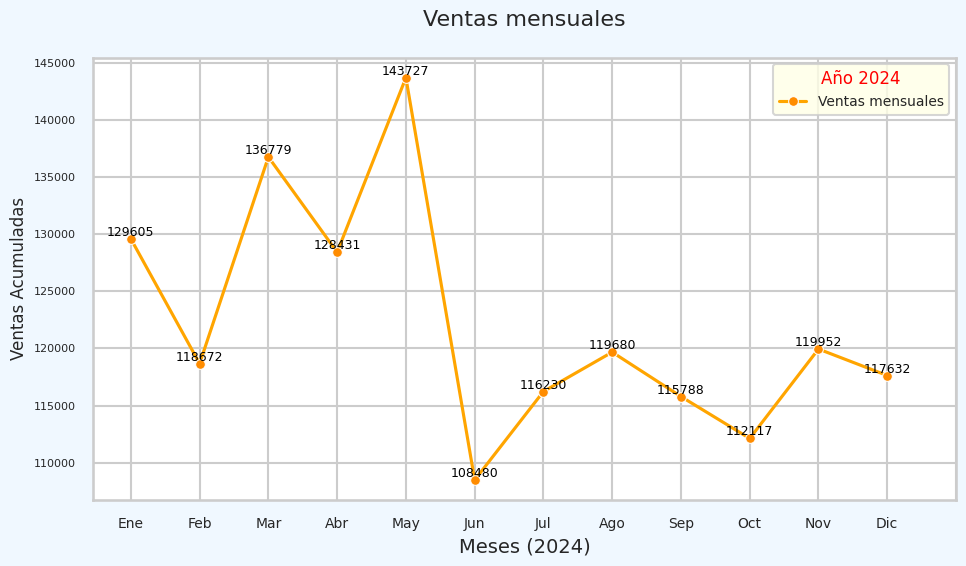

In [308]:
# @title
# Generamos un gráfico de lineas (serie de tiempo)
# que muestre la evolución de las ventas en el año (2024 por mes)
import matplotlib.pyplot as plt
import seaborn as sns
aMes = ["","Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

# Estilo
sns.set_theme(style="whitegrid", context="talk")
custom_palette = sns.color_palette("Set2")

# Definimos el tamaño del lienzo
plt.figure(figsize=(10,6), facecolor="#f0f8ff")

# Graficamos
ax = sns.lineplot(data=ventas_mes, x="mes", y="ventas_mes", label="Ventas mensuales",
         marker="o", markerfacecolor='#FF8C00', markersize=7, color="orange")

legend_title = ax.legend_.get_title()
legend_title.set_color("red")

# Ticks (valores de eje)
plt.xticks(ticks=aMes, fontsize=10)
plt.yticks(fontsize=8)

for x, y in zip(ventas_mes["mes"], ventas_mes["ventas_mes"]):
    ax.text(
        x, y,
        f"{y:.0f}",       # etiqueta (sin decimales)
        ha="center",
        va="bottom",      # posición arriba del punto
        fontsize=9,
        color="black",
        fontweight="normal"
    )

# Ajustes de título y ejes
plt.title('Ventas mensuales\n', fontsize=16)
plt.xlabel('Meses (2024)', fontsize=14)
plt.ylabel('Ventas Acumuladas', fontsize=12)
plt.legend(title='Año 2024', fontsize=10, title_fontsize=12, facecolor='#ffffe6')
legend_title = ax.legend_.get_title()
legend_title.set_color("red")
plt.tight_layout()

plt.show()


### **B.** &ensp; Cantidad de productos totales vendidos por mes

In [289]:
# Agrupamos por mes y agregamos por cantidad
cantidades_mes = df_ventas_final.groupby("mes", as_index=False).agg(
    cantidad_mes=("cantidad", "sum")
)
# Visualizamos
cantidades_mes.head()

,mes,cantidad_mes
0,1,1741
1,2,1607
2,3,1792
3,4,1715
4,5,1812


In [315]:
# @title
# Estilo y paleta

# sns.set_theme(               # set_theme combina estilo + contexto + paleta
#    style="whitegrid",       # opciones: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'
#    context="notebook",          # escala general: 'paper', 'notebook', 'talk', 'poster'
#    palette="Set3" )          # paleta de colores base: "deep", "muted", "pastel" / Set1, Set2, Set3


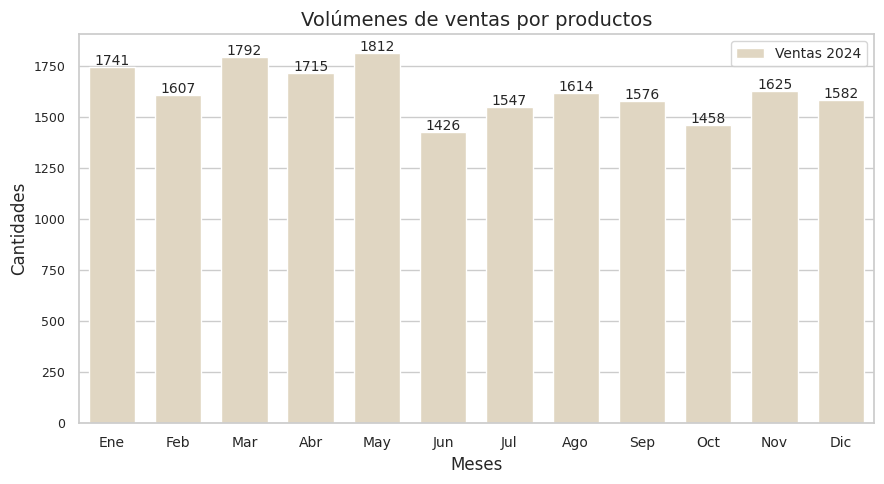

In [329]:
aMeses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
# Ajustamos tamaño del lienzo
plt.figure(figsize=(9,5))
set3_colors = sns.color_palette('Set3').as_hex()
set3_colors[0] = '#e5d8bd'

sns.set_theme( style="whitegrid", palette=sns.color_palette(set3_colors))
#               context="notebook")


ax = sns.barplot(data=cantidades_mes, x='mes', y='cantidad_mes', width=0.7,
                 label="Ventas 2024")

# Agregar etiquetas arriba de las barras
for i, valor in enumerate(cantidades_mes['cantidad_mes']):
    ax.text(
        i,                       # posición x de la etiqueta
        valor + 10,                   # posición y (ligeramente arriba de la barra)
        str(valor),              # texto
        ha='center', fontsize=10
    )

# Ticks (valores de eje)
plt.tick_params(axis='y', labelsize=9)

# Fix the UserWarning: explicitly set ticks before setting tick labels
# Get the current tick locations set by Seaborn's barplot
tick_locations = ax.get_xticks()
ax.set_xticks(tick_locations) # Fix the number of ticks
ax.set_xticklabels(aMeses, fontsize=10) # poner labels

# Ajustes de título y ejes
plt.title('Volúmenes de ventas por productos', fontsize=14)
plt.xlabel('Meses')
plt.ylabel('Cantidades')
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout() # ajuste automatico
plt.show()

### **C.** &ensp; Volumen de venta por categorías

In [331]:
df_ventas.head()

# Agrupamos por categoría y agregamos por valor_venta
ventas_categoria = df_ventas_final.groupby("categoria", as_index=False).agg(
    ventas_totales=("valor_venta", "sum")
)

ventas_categoria.head()

,categoria,ventas_totales
0,Decoración,479216.09
1,Electrodomésticos,505299.63
2,Electrónica,482577.80


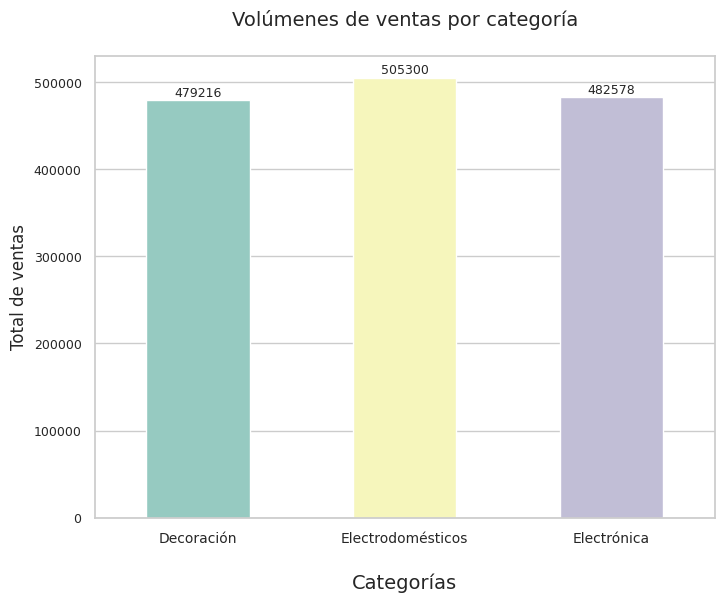

In [343]:
# Estilo y paleta
sns.set_theme(               # set_theme combina estilo + contexto + paleta
    style="whitegrid",       # opciones: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'
    context="notebook",          # escala general: 'paper', 'notebook', 'talk', 'poster'
    palette="Set3"           # paleta de colores base: "deep", "muted", "pastel" / Set1, Set2, Set3
)

# Ajustamos tamaño del lienzo
plt.figure(figsize=(8,6))

# Crear el barplot
ax = sns.barplot(data=ventas_categoria, x='categoria', y='ventas_totales', hue='categoria', width=0.5)

# Agregar etiquetas arriba de las barras
for i, valor in enumerate(ventas_categoria['ventas_totales']):
    str_valor = f"{valor:.0f}"
    ax.text(
        i,                        # posición x de la etiqueta
        valor +5000,                   # posición y (ligeramente arriba de la barra)
        f"{valor:.0f}",           # texto
        ha='center', fontsize=9
    )

# Ticks (valores de eje)
plt.tick_params(axis='y', labelsize=9)
plt.tick_params(axis='x', labelsize=10)

# Ajustes de título y ejes
plt.title('Volúmenes de ventas por categoría\n', fontsize=14)
plt.xlabel('\nCategorías',fontsize=14)
plt.ylabel('Total de ventas')
# plt.legend(loc='upper right', fontsize=10) # Removed this line as seaborn handles the legend with hue

# plt.tight_layout() # ajuste automatico
plt.show()


.






.

### **D.** &ensp; Impacto de la campaña de marketing en las ventas I

Trazamos una linea vertical al primer grafico ventas por mes

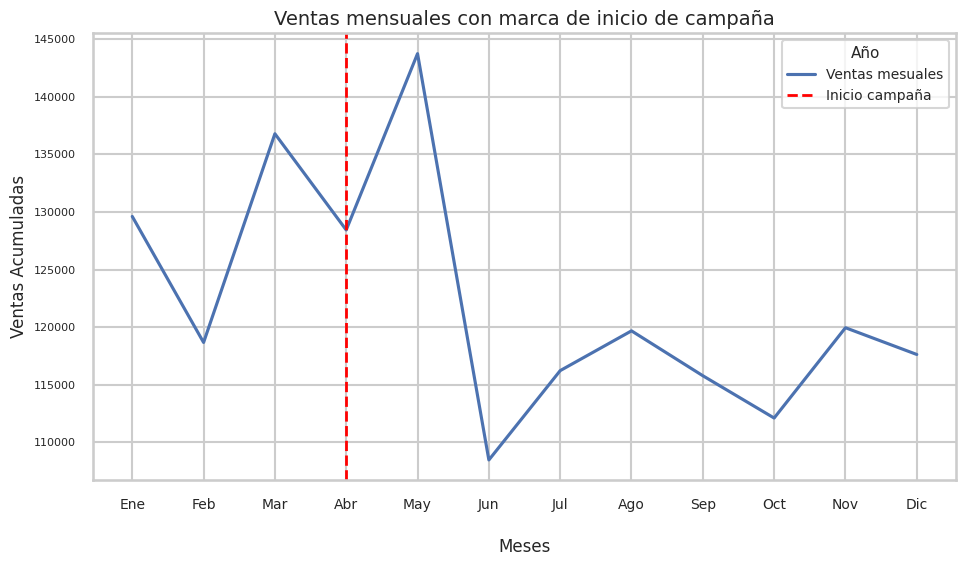

In [352]:
# Generamos un gráfico de lineas (serie de tiempo)
# que muestre la evolución de las ventas en el año (2024 por mes)
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set_theme(style="whitegrid", context="talk")
custom_palette = sns.color_palette("Set2")

plt.figure(figsize=(10,6))

# Graficamos
sns.lineplot(data=ventas_mes, x="mes", y="ventas_mes", label="Ventas mesuales" )

# línea vertical que marque el inicio de campaña
plt.axvline(3, color="red", linewidth=2, linestyle="--",
            label="Inicio campaña")

# Ticks (valores de eje)
plt.xticks(fontsize=10)
plt.yticks(fontsize=8)

# Ajustes de título y ejes
plt.title('Ventas mensuales con marca de inicio de campaña', fontsize=14)
plt.xlabel('\nMeses', fontsize=12)
plt.ylabel('Ventas Acumuladas', fontsize=12)
plt.legend(title='Año', fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()


### **E.** &ensp; Impacto de la campaña de marketing en las ventas **II**

Revisar la sección Etapa 2 - Integración de datos
Allí, luego de unir los dataframes df_ventas con df_marketing, se generan 2 dataframes independientes, cada uno conteniendo las ventas que se hicieron dentro de algún período de marketing, y otro con las ventas que se realizaron fuera de campaña.
<BR>
Así surgen:
* ventas_con_marketing_final
* ventas_sin_marketing_final

In [345]:
ventas_con_marketing_final.head()

,producto,ventas_producto_cm,costo_marketing,ganancia_producto_cm
27,Smartphone,8965.03,101.92,8863.11
21,Parlantes Bluetooth,7863.56,84.00,7779.56
10,Cámara digital,7302.09,87.36,7214.73
9,Cuadro decorativo,6968.20,79.05,6889.15
29,Televisor,6863.97,47.52,6816.45


In [346]:
ventas_sin_marketing_final.head()

,producto,ventas_producto_sm
19,Lámpara de mesa,78037.97
20,Microondas,69339.39
3,Auriculares,68060.55
5,Cafetera,58188.05
13,Freidora eléctrica,49955.79


In [347]:
ventas_con_sin_marketing = pd.merge(ventas_con_marketing_final, ventas_sin_marketing_final, on="producto", how="inner")

ventas_con_sin_marketing = ventas_con_sin_marketing.sort_values(by=["ventas_producto_cm"], ascending=False)

ventas_con_sin_marketing.head()


,producto,ventas_producto_cm,costo_marketing,ganancia_producto_cm,ventas_producto_sm
0,Smartphone,8965.03,101.92,8863.11,45167.41
1,Parlantes Bluetooth,7863.56,84.00,7779.56,39915.90
2,Cámara digital,7302.09,87.36,7214.73,37915.87
3,Cuadro decorativo,6968.20,79.05,6889.15,47329.40
4,Televisor,6863.97,47.52,6816.45,40174.07


In [348]:
# Transformar a formato largo
df_long = ventas_con_sin_marketing[["producto","ventas_producto_cm", "ventas_producto_sm"]]
df_long = df_long.melt(id_vars="producto",
                        var_name="modalidad",
                        value_name="valores")

# df_long = df_long.sort_values(by=["valores", "modalidad"], ascending=True)
df_long.head()

,producto,modalidad,valores
0,Smartphone,ventas_producto_cm,8965.03
1,Parlantes Bluetooth,ventas_producto_cm,7863.56
2,Cámara digital,ventas_producto_cm,7302.09
3,Cuadro decorativo,ventas_producto_cm,6968.20
4,Televisor,ventas_producto_cm,6863.97


# BORRAR !!!

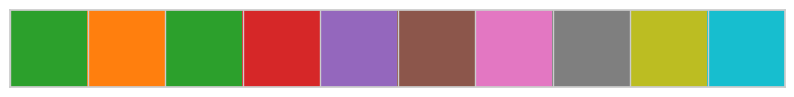

['#2ca02c', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


In [357]:
# PARA VER COLORES DE PALETTE Y CAMBIARLOS !!!!!
#print(['#1f77b4', '#2ca02c', '#ff7f0e'])
colores = sns.color_palette('tab10').as_hex()
colores[0] = '#2ca02c'
sns.palplot(sns.color_palette(colores)) # Para visualizar
plt.show()
print(colores)


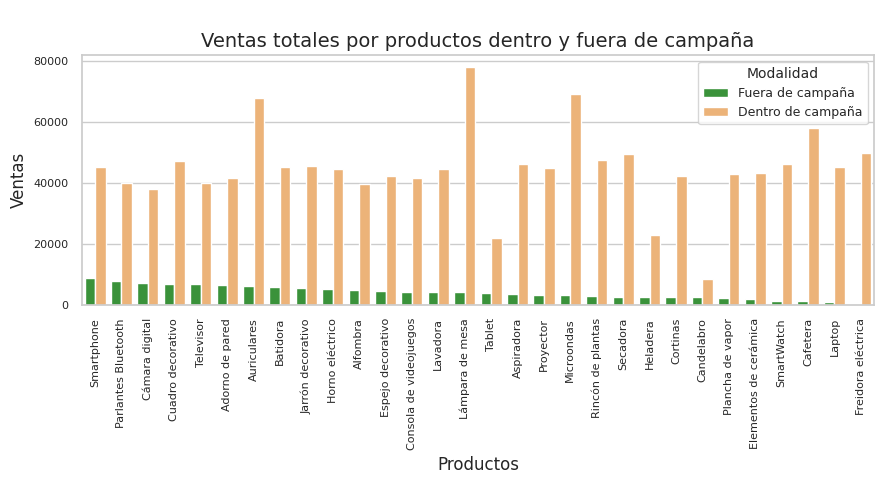

In [365]:
# Estilo y paleta
sns.set_theme(               # set_theme combina estilo + contexto + paleta
    style="whitegrid",       # opciones: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'
    context="notebook",          # escala general: 'paper', 'notebook', 'talk', 'poster'
    palette="tab10"           # paleta de colores base: "deep", "muted", "pastel" / Set1, Set2, Set3
)

plt.figure(figsize=(9,5))

colores = sns.color_palette('tab10').as_hex()
colores[0] = '#2ca02c'
colores[1] = '#ffb366'
#sns.palplot(sns.color_palette(colores))

sns.set_theme( style="whitegrid", palette=sns.color_palette(colores))

sns.barplot(data=df_long, x="producto", y="valores", hue="modalidad", width=0.8)

# sns.barplot(data=df_long, x="Trimestre", y="Ventas", hue="Producto", width=0.8)
#Invertimos Productos por Trimestre

# Ticks (valores de eje)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

# Ajustes de título y ejes
plt.title('\nVentas totales por productos dentro y fuera de campaña', fontsize=14)
plt.xlabel('Productos')
plt.ylabel('Ventas')

# Obtener handles (cuadritos de color) y labels originales del gráfico
handles, labels = plt.gca().get_legend_handles_labels()

# Reemplazar solo los textos de la leyenda, manteniendo colores
plt.legend(
    handles,
    ["Fuera de campaña", "Dentro de campaña"],
    title="Modalidad",
    fontsize=9,
    title_fontsize=10
)
plt.tight_layout()
plt.show()


In [350]:
ventas_marketing_rs.head()

,id_venta,producto,precio_unit,cantidad,fecha_venta,categoria,valor_venta,id_campanha,canal,costo_mrkt,fecha_inicio,fecha_fin
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,1,RRSS,5.27,2024-04-27,2024-06-04
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,2,RRSS,5.88,2024-05-30,2024-06-29
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10,2024-07-24,2024-08-30
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,4,RRSS,4.53,2024-05-31,2024-07-15
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,3,RRSS,5.10,2024-07-24,2024-08-30


In [351]:
df_test = ventas_marketing_rs.groupby(["id_venta", "producto"]).agg(
    {"valor_venta": "first"})
df_test1 = df_test.groupby("producto").agg(
    {"valor_venta": "sum"})

df_test2 = df_test1.sort_values(by="valor_venta", ascending=False)
df_test2.head()

,valor_venta
producto,
Lámpara de mesa,82276.38
Auriculares,74175.58
Microondas,72562.89
Cafetera,59607.31
Cuadro decorativo,54297.60


# Visualización con Plotly

## 4 - Presentación Final

Escribir aquí las observaciones, hallazgos y recomendaciones.

# ==========================================================

# ANEXO

## PROBABLES MEJORAS A FUTURO

### *Trabajo en curso*

1 Crear lista categorias = df_ventas_final["categoria"].unique()  

2 Crear tabla df_producto con id_producto, producto, id_categoria, categoria

Se observó que:
1. Las ventas contienen productos con la misma denominación, sin ninguna id como para identificarlos. Pertenecen a distintas ventas individuales y tienen distinto precio.

2. Por tal razón es dificil hacer una evaluación seria del resultado de la campaña publicitaria, porque corresponde a distintos productos agrupados, con precio sin adjudicar.

3. La campaña de marketing posee el costo publicitario por producto (generico/agregado) pero no hay como relacionarlo con el costo_unitario, ni con el precio_venta

4. Sacar un precio_promedio, no estoy seguro que sirva mucho, porque la venta podria haberse hecho a un valor menor que el precio_unitario_promedio, debido a la gran dispersión de precios

Hemos visto que para el producto "Adorno de pared", los precios estan distibuidos en 3 segmentos o rangos, la idea es hacer un promedio por rango y
luego renombrar los productos segun el rango, por ej:
"Adorno de pared" => "Adorno de pared R1"

De esta manera en lugar de tener 100 productos genericos los tendriamos divididos por rango de precios y con un nuevo nombre_producto que los represente
  


.  


Borré el código anexo hasta la version definitiva